In [2]:
### In this file, I will show you how to visualize 
### the data using matplotlib.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from pathlib import Path

In [4]:
def _find_data_dir(required_files=("kappa.mat", "basis.mat")):
    candidates = [Path("."), Path("./data")]
    for candidate in candidates:
        if all((candidate / filename).exists() for filename in required_files):
            return candidate
    checked = ", ".join(str(candidate.resolve()) for candidate in candidates)
    raise FileNotFoundError(
        "Could not find the data files. Run this notebook from either the "
        f"repository root or the data folder. Checked: {checked}"
    )


DATA_DIR = _find_data_dir()
GRID_SIZE = 128
NUM_BASIS = 12

def _read_h5_array(path, key, leading_dim, label):
    with h5py.File(path, "r") as f:
        arr = f[key][()]
    print(f"shape of loaded {label} = {arr.shape}")
    if arr.shape[0] == leading_dim:
        arr = np.transpose(arr)
        print(f"After transpose, the shape of {label} = {arr.shape}")
    return arr


def load_pair(data_dir, kappa_name, basis_name, grid_size=128, num_basis=12):
    kappa = _read_h5_array(data_dir / kappa_name, "Ks", leading_dim=1, label=kappa_name)
    basis = _read_h5_array(data_dir / basis_name, "bfs", leading_dim=num_basis, label=basis_name)

    pixels_per_sample = grid_size * grid_size
    if kappa.size % pixels_per_sample != 0:
        raise ValueError(f"Kappa data size {kappa.size} is not divisible by {pixels_per_sample}.")
    n_samples = kappa.size // pixels_per_sample
    expected_basis_shape = (n_samples * pixels_per_sample, num_basis)
    if basis.shape != expected_basis_shape:
        raise ValueError(f"Expected basis shape {expected_basis_shape}, but got {basis.shape}.")

    kappa = kappa.reshape(n_samples, grid_size, grid_size).astype(np.float32)
    basis = basis.reshape(n_samples, pixels_per_sample, num_basis).astype(np.float32)
    return kappa, basis


def load_all_data(data_dir=DATA_DIR, grid_size=GRID_SIZE, num_basis=NUM_BASIS):
    pairs = [
        ("kappa.mat", "basis.mat"),
        ("kappa2.mat", "basis2.mat"),
    ]
    xs, ys = zip(*(load_pair(data_dir, x_name, y_name, grid_size, num_basis) for x_name, y_name in pairs))
    x_all = np.concatenate(xs, axis=0)
    y_all = np.concatenate(ys, axis=0)
    print("x_all:", x_all.shape, "y_all:", y_all.shape)
    return x_all, y_all

shape of loaded kappa.mat = (1, 32768000)
After transpose, the shape of kappa.mat = (32768000, 1)
shape of loaded basis.mat = (12, 32768000)
After transpose, the shape of basis.mat = (32768000, 12)
shape of loaded kappa2.mat = (1, 32768000)
After transpose, the shape of kappa2.mat = (32768000, 1)
shape of loaded basis2.mat = (12, 32768000)
After transpose, the shape of basis2.mat = (32768000, 12)
x_all: (4000, 128, 128) y_all: (4000, 16384, 12)
We choose the 3911-th sample, the 226-th coarse element
The shape of kappa is (128, 128)
The shape of sample_basis is (16384, 12)
The shape of coarse_elem is (16, 12)
The shape of basis_block is (4, 4, 12)
The shape of kappa_patch is (4, 4)


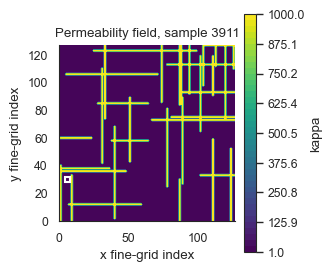

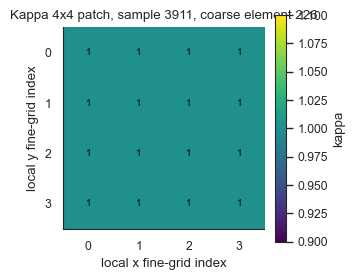

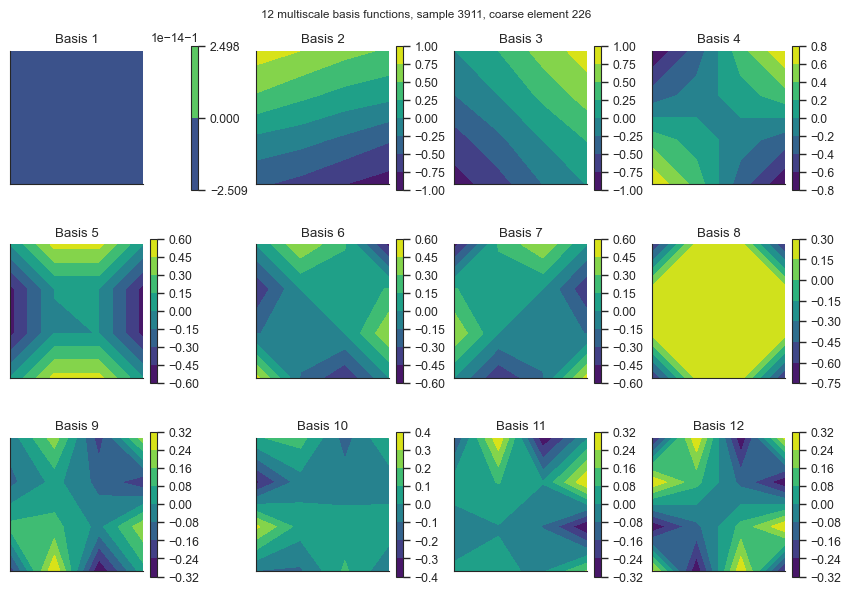

In [18]:
import random
import matplotlib as mpl
from matplotlib.patches import Rectangle

RANDOM_SEED = 2256
BASIS_GRID_SIZE = 4

sns.set_theme(context="paper", style="white")
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.size": 7,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
})


def save_pub_py(fig, filename, dpi=600):
    fig.savefig(f"{filename}.svg", bbox_inches="tight")
    fig.savefig(f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(f"{filename}.tiff", dpi=dpi, bbox_inches="tight")


def _basis_block_count(basis_sample, basis_grid_size=4):
    values_per_block = basis_grid_size * basis_grid_size
    if basis_sample.shape[0] % values_per_block != 0:
        raise ValueError(
            f"Basis sample has {basis_sample.shape[0]} rows, which is not divisible by "
            f"{values_per_block} values per {basis_grid_size}x{basis_grid_size} block."
        )
    return basis_sample.shape[0] // values_per_block


def _coarse_elem_to_grid(coarse_elem, basis_grid_size=4):
    num_basis = coarse_elem.shape[1]
    return np.stack(
        [coarse_elem[:, basis_idx].reshape(basis_grid_size, basis_grid_size) for basis_idx in range(num_basis)],
        axis=-1,
    ).astype(np.float32)


def _basis_block_to_grid(basis_sample, basis_block_idx, basis_grid_size=4, num_basis=None):
    if num_basis is None:
        num_basis = basis_sample.shape[1]
    values_per_block = basis_grid_size * basis_grid_size
    if basis_sample.ndim != 2 or basis_sample.shape[1] != num_basis:
        raise ValueError(f"Expected basis sample shape (n, {num_basis}), but got {basis_sample.shape}.")

    n_basis_blocks = _basis_block_count(basis_sample, basis_grid_size)
    if not 0 <= basis_block_idx < n_basis_blocks:
        raise IndexError(f"basis_block_idx={basis_block_idx} is outside [0, {n_basis_blocks}).")

    start = basis_block_idx * values_per_block
    stop = start + values_per_block
    basis_block = basis_sample[start:stop, :]
    return _coarse_elem_to_grid(basis_block, basis_grid_size)


def _basis_block_slices(coarse_elem_idx, grid_size=128, basis_grid_size=4):
    if grid_size % basis_grid_size != 0:
        raise ValueError(f"grid_size={grid_size} must be divisible by basis_grid_size={basis_grid_size}.")
    blocks_per_axis = grid_size // basis_grid_size
    zero_based_idx = coarse_elem_idx - 1
    basis_row = zero_based_idx // blocks_per_axis
    basis_col = zero_based_idx % blocks_per_axis
    row_start = basis_row * basis_grid_size
    col_start = basis_col * basis_grid_size
    return slice(row_start, row_start + basis_grid_size), slice(col_start, col_start + basis_grid_size)


def _kappa_patch_from_coarse_elem(kappa_field, coarse_elem_idx, grid_size=128, basis_grid_size=4):
    row_slice, col_slice = _basis_block_slices(coarse_elem_idx, grid_size, basis_grid_size)
    return kappa_field[row_slice, col_slice]


def _contour_levels(values, n_levels=41):
    values = np.asarray(values)
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    if np.isclose(vmin, vmax):
        delta = max(abs(vmin) * 0.01, 1e-12)
        return np.linspace(vmin - delta, vmax + delta, n_levels), "viridis"
    if vmin < 0 < vmax:
        limit = max(abs(vmin), abs(vmax))
        return np.linspace(-limit, limit, n_levels), "RdBu_r"
    return np.linspace(vmin, vmax, n_levels), "viridis"


def plot_kappa_field(kappa_field, sample_idx, coarse_elem_idx, grid_size=128, basis_grid_size=4):
    row_slice, col_slice = _basis_block_slices(coarse_elem_idx, grid_size, basis_grid_size)
    x = np.arange(grid_size)
    y = np.arange(grid_size)

    fig, ax = plt.subplots(figsize=(3.2, 3.0), constrained_layout=True)
    levels, cmap = _contour_levels(kappa_field)
    cmap = 'viridis'
    contour = ax.contourf(x, y, kappa_field, levels=levels, cmap=cmap)
    ax.add_patch(Rectangle(
        (col_slice.start, row_slice.start),
        basis_grid_size,
        basis_grid_size,
        fill=False,
        edgecolor="white",
        linewidth=1.5,
    ))
    ax.set_title(f"Permeability field, sample {sample_idx}")
    ax.set_xlabel("x fine-grid index")
    ax.set_ylabel("y fine-grid index")
    ax.set_aspect("equal")
    fig.colorbar(contour, ax=ax, shrink=0.82, label="kappa")
    return fig, ax


def plot_kappa_patch(kappa_patch, sample_idx, coarse_elem_idx):
    fig, ax = plt.subplots(figsize=(3.2, 3.0), constrained_layout=True)
    image = ax.imshow(kappa_patch, cmap="viridis", origin="upper")
    ax.set_title(f"Kappa 4x4 patch, sample {sample_idx}, coarse element {coarse_elem_idx}")
    ax.set_xticks(np.arange(kappa_patch.shape[1]))
    ax.set_yticks(np.arange(kappa_patch.shape[0]))
    ax.set_xlabel("local x fine-grid index")
    ax.set_ylabel("local y fine-grid index")

    threshold = float(np.nanmin(kappa_patch) + 0.5 * (np.nanmax(kappa_patch) - np.nanmin(kappa_patch)))
    for row in range(kappa_patch.shape[0]):
        for col in range(kappa_patch.shape[1]):
            value = float(kappa_patch[row, col])
            text_color = "white" if value > threshold else "black"
            ax.text(col, row, f"{value:.2g}", ha="center", va="center", color=text_color, fontsize=7)

    fig.colorbar(image, ax=ax, shrink=0.82, label="kappa")
    return fig, ax


def plot_basis_functions(basis_block, sample_idx, coarse_elem_idx):
    x = np.arange(basis_block.shape[1])
    y = np.arange(basis_block.shape[0])
    n_basis = basis_block.shape[-1]

    fig, axes = plt.subplots(3, 4, figsize=(8.4, 5.8), constrained_layout=True)
    axes_flat = axes.ravel()

    for basis_idx, ax in enumerate(axes_flat[:n_basis]):
        last_contour = ax.contourf(x, y, basis_block[:, :, basis_idx], cmap="viridis")
        ax.set_title(f"Basis {basis_idx + 1}")
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(last_contour, ax=ax, shrink=0.78)
    for ax in axes_flat[n_basis:]:
        ax.axis("off")

    fig.suptitle(
        f"{n_basis} multiscale basis functions, sample {sample_idx}, "
        f"coarse element {coarse_elem_idx}",
        y=1.02,
    )
    return fig, axes


xx, yy = load_all_data(DATA_DIR, GRID_SIZE, NUM_BASIS)

random.seed(RANDOM_SEED)
sample_idx = random.randint(0, xx.shape[0] - 1)
sample_kappa = xx[sample_idx].squeeze()
sample_basis = yy[sample_idx]

n_coarse_elements = _basis_block_count(sample_basis, BASIS_GRID_SIZE)
coarse_elem_idx = random.randint(1, n_coarse_elements)
coarse_elem = sample_basis[(coarse_elem_idx - 1) * 16: 16 + (coarse_elem_idx - 1) * 16]
basis_block = _coarse_elem_to_grid(coarse_elem, BASIS_GRID_SIZE)
kappa_patch = _kappa_patch_from_coarse_elem(sample_kappa, coarse_elem_idx, GRID_SIZE, BASIS_GRID_SIZE)

print(f"We choose the {sample_idx}-th sample, the {coarse_elem_idx}-th coarse element")
print(f"The shape of kappa is {sample_kappa.shape}")
print(f"The shape of sample_basis is {sample_basis.shape}")
print(f"The shape of coarse_elem is {coarse_elem.shape}")
print(f"The shape of basis_block is {basis_block.shape}")
print(f"The shape of kappa_patch is {kappa_patch.shape}")

fig_kappa, ax_kappa = plot_kappa_field(sample_kappa, sample_idx, coarse_elem_idx, GRID_SIZE, BASIS_GRID_SIZE)
fig_kappa_patch, ax_kappa_patch = plot_kappa_patch(kappa_patch, sample_idx, coarse_elem_idx)
fig_basis, axes_basis = plot_basis_functions(basis_block, sample_idx, coarse_elem_idx)
plt.show()
